# Comparing Experiments

This notebook compares results across different experiments.

In [69]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Averaging Across Seeds 
*Experiments: 10–13*  

This section averages the ResNet-18 candidate experiments, which were run across four different seeds.

In [70]:
# Columns to average across seeds
METRIC_COLUMNS = [
    "test_acc",
    "test_weighted_f1_avg",
    "test_unseen_matched_acc",
    "test_unseen_matched_weighted_f1_avg",
]


def load_results(label):
    """
    Load results for a given label from the parquet file for experiments 10–13.

    Args:
        label (str): The label for which to load results.

    Returns:
        pd.DataFrame: A DataFrame containing the loaded results.
    """

    label = label + "_classify"
    df = pd.read_parquet(Path("../results") / label / "experiments.parquet")
    df = df[df["experiment_number"].isin([10, 11, 12, 13])]
    return df


def average_seed_results(results):
    """
    Return mean and standard deviation for each candidate across seeds, rounded to 2 DP.

    Args:
        results (pd.DataFrame): A DataFrame containing the results to be averaged.

    Returns:
        pd.DataFrame: A DataFrame containing the mean and standard deviation for each
            candidate across seeds.
    """

    seed_counts = results.groupby("run_name")["seed"].nunique()
    summary = results.groupby("run_name")[METRIC_COLUMNS].agg(["mean", "std"])
    summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
    summary.insert(0, "n_seeds", seed_counts)
    return summary.reset_index().round(2)


def export_seed_comparison(label):
    """
    Average seed results, export them to CSV, and return the summary.

    Args:
        label (str): The label for which to export seed comparison.

    Returns:
        pd.DataFrame: A DataFrame containing the averaged seed results.
    """

    summary = average_seed_results(load_results(label))
    filename = "candidate_seed_comparison"

    output_dir = Path("../acc_f1_tables") / f"{label}_classify"
    output_dir.mkdir(parents=True, exist_ok=True)
    summary.to_csv(output_dir / f"{filename}.csv", index=False)
    return summary

In [71]:
# Configuration and plotting settings
CONFIGURATION_NAMES = {
    "pad_none": "Pad: None",
    "pad_jitter": "Pad: Jitter",
    "pad_flip_jitter": "Pad: Jitter + Flip",
    "crop_all": "Crop: All",
}
SEED_ORDER = [129, 130, 131, 132]
ACCURACY_PANELS = [
    ("test_acc", "Test Accuracy"),
    ("test_unseen_matched_acc", "Unseen Matched Accuracy"),
]


def plot_seed_accuracy_comparison(results, label):
    """
    Plot individual-seed and mean accuracies for the candidate configurations.

    Args:
        results (pd.DataFrame): Experiment results returned by load_results.
        label (str): Classification label, either 'object' or 'object_region'.
    """

    configuration_order = list(CONFIGURATION_NAMES)
    x_positions = list(range(len(configuration_order)))
    seed_colours = sns.color_palette("deep", n_colors=len(SEED_ORDER))

    # Create both panels with the same styling and configuration order
    with sns.axes_style("darkgrid"):
        fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    for panel_label, ax, (metric, metric_title) in zip(["a", "b"], axs, ACCURACY_PANELS):
        # Plot each seed at the centre of its configuration category
        for seed, colour in zip(SEED_ORDER, seed_colours):
            seed_results = (
                results[results["seed"] == seed]
                .set_index("run_name")
                .reindex(configuration_order)
            )
            ax.scatter(
                x_positions,
                seed_results[metric],
                color=colour,
                edgecolor="white",
                linewidth=0.6,
                s=55,
                label=f"Seed {seed}",
                zorder=3,
            )

        means = results.groupby("run_name")[metric].mean().reindex(configuration_order)
        ax.scatter(
            x_positions,
            means,
            color="black",
            edgecolor="white",
            linewidth=0.8,
            marker="D",
            s=80,
            label="Mean",
            zorder=4,
        )

        # Use a separate, data-driven zoom for each accuracy metric
        minimum = results[metric].min()
        maximum = results[metric].max()
        margin = max((maximum - minimum) * 0.1, 0.5)
        ax.set_ylim(minimum - margin, maximum + margin)
        ax.yaxis.set_major_formatter(lambda value, _: f"{value:g}%")

        ax.set_title(
            f"({panel_label}) {metric_title}",
            fontsize=14,
            fontweight="normal",
        )
        ax.set_xlabel("Configuration")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks(x_positions, CONFIGURATION_NAMES.values())

    # Place one shared legend above the panels to show that it applies to both
    handles, legend_labels = axs[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        title="Result",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(legend_labels),
    )
    fig.tight_layout(rect=(0, 0, 1, 0.82))

    output_dir = Path("../plots")
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_dir / f"{label}_candidate_seed_accuracies.png",
        dpi=300,
        bbox_inches="tight",
    )

#### Object

In [72]:
export_seed_comparison("object")

,run_name,n_seeds,test_acc_mean,test_acc_std,test_weighted_f1_avg_mean,test_weighted_f1_avg_std,test_unseen_matched_acc_mean,test_unseen_matched_acc_std,test_unseen_matched_weighted_f1_avg_mean,test_unseen_matched_weighted_f1_avg_std
0,crop_all,4,86.29,2.38,0.86,0.02,56.19,2.23,0.63,0.02
1,pad_flip_jitter,4,91.66,0.89,0.92,0.01,50.61,1.03,0.56,0.02
2,pad_jitter,4,93.28,0.97,0.93,0.01,51.16,2.15,0.55,0.04
3,pad_none,4,93.86,1.20,0.94,0.01,46.66,2.89,0.51,0.03


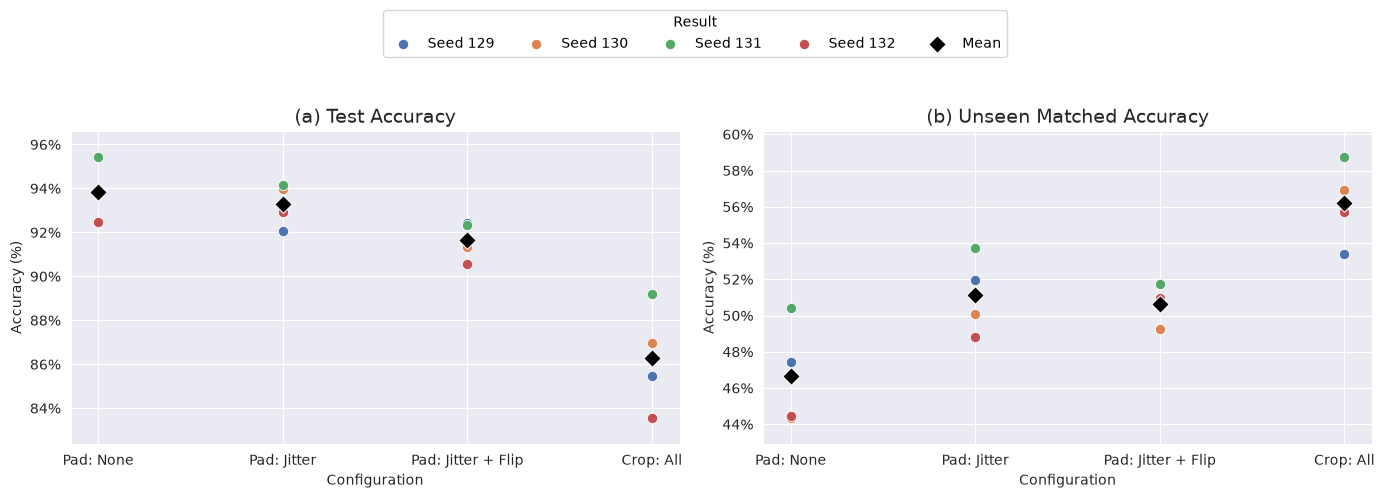

In [73]:
object_results = load_results("object")
plot_seed_accuracy_comparison(object_results, "object")

#### Object Region

In [74]:
export_seed_comparison("object_region")

,run_name,n_seeds,test_acc_mean,test_acc_std,test_weighted_f1_avg_mean,test_weighted_f1_avg_std,test_unseen_matched_acc_mean,test_unseen_matched_acc_std,test_unseen_matched_weighted_f1_avg_mean,test_unseen_matched_weighted_f1_avg_std
0,crop_all,4,80.75,1.77,0.80,0.02,39.63,1.86,0.45,0.01
1,pad_flip_jitter,4,87.29,1.10,0.87,0.01,34.67,2.69,0.38,0.01
2,pad_jitter,4,87.25,3.21,0.87,0.03,32.33,1.47,0.34,0.01
3,pad_none,4,91.23,1.64,0.91,0.02,29.79,1.26,0.30,0.02


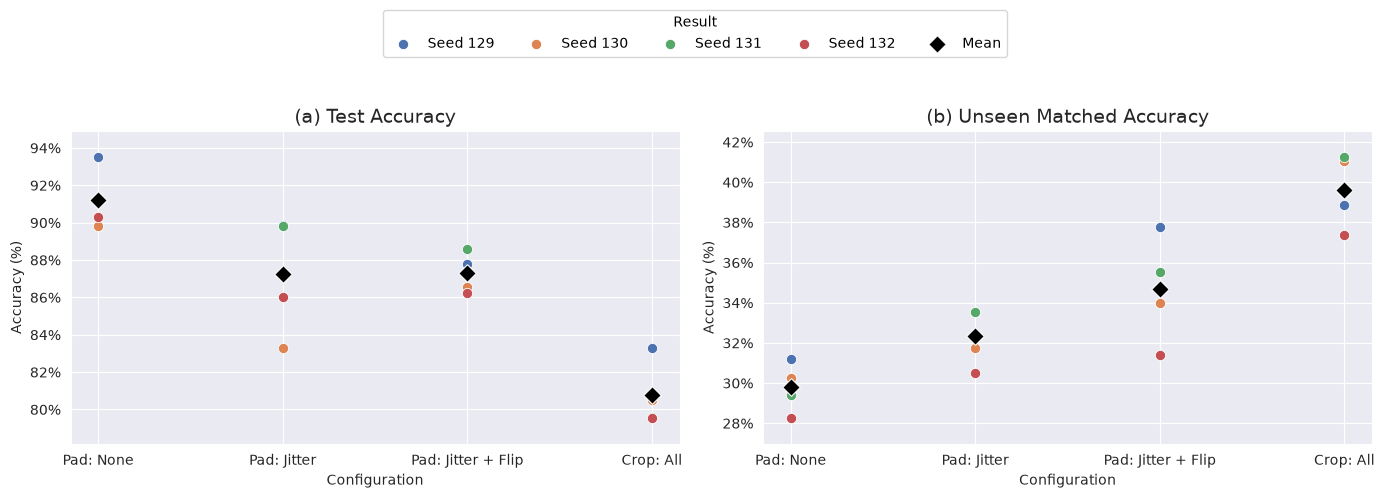

In [75]:
object_region_results = load_results("object_region")
plot_seed_accuracy_comparison(object_region_results, "object_region")

### Effect of Force-Level Conditioning
*Experiments: ResNet-18 Main (16) and force-level conditioned (1)*  

This section shows the change from ResNet-18 Main to the force-level-conditioned model. Accuracy changes are percentage points, while weighted F1 changes use the original 0–1 scale.

In [76]:
CONDITIONING_METRIC_COLUMNS = [
    "test_acc",
    "test_weighted_f1_avg",
    "test_unseen_matched_acc",
    "test_unseen_matched_weighted_f1_avg",
    "test_unseen_related_acc",
    "test_unseen_related_weighted_f1_avg",
]


def load_conditioning_results(label):
    """
    Load the Main and conditioned results for a given label.

    Args:
        label (str): The label for which to load results.

    Returns:
        tuple[pd.Series, pd.Series]: The Main and conditioned result rows.
    """

    main_path = Path("../results") / f"{label}_classify" / "experiments.parquet"
    main = pd.read_parquet(main_path).query("experiment_number == 16").iloc[0]
    conditioned_path = (
        Path("../results") / f"{label}_conditioned_classify" / "experiments.parquet"
    )
    conditioned = pd.read_parquet(conditioned_path).query("experiment_number == 1").iloc[0]
    return main, conditioned


def calculate_conditioning_deltas(main, conditioned):
    """
    Calculate signed conditioned-minus-Main metric changes.

    Args:
        main (pd.Series): The ResNet-18 Main result row.
        conditioned (pd.Series): The conditioned result row.

    Returns:
        dict: The signed change for each comparison metric.
    """

    deltas = conditioned[CONDITIONING_METRIC_COLUMNS] - main[CONDITIONING_METRIC_COLUMNS]
    return {f"{metric}_delta": value for metric, value in deltas.items()}


def export_conditioning_comparison():
    """
    Export conditioned-minus-Main metric changes for both labels.

    Returns:
        pd.DataFrame: A DataFrame containing the conditioned-minus-Main metric changes
    """

    rows = []
    for label in ["object", "object_region"]:
        main, conditioned = load_conditioning_results(label)
        deltas = calculate_conditioning_deltas(main, conditioned)
        row = {"label": label}
        row.update(
            {
                metric: f"{value:+.4f}" if "f1" in metric else f"{value:+.2f}"
                for metric, value in deltas.items()
            }
        )
        rows.append(row)

    # Create a DataFrame from the rows and export it to CSV
    comparison = pd.DataFrame(rows)
    comparison.to_csv("../acc_f1_tables/conditioning_comparison.csv", index=False)
    return comparison

In [77]:
def plot_conditioning_comparison(comparison):
    """
    Plot and save the conditioned-minus-main metric changes.

    Args:
        comparison (pd.DataFrame): A DataFrame containing the comparison data.
    """

    # Set the index to the label column and convert all values to float for plotting
    plot_data = comparison.set_index("label").astype(float)

    # Express weighted F1 changes in percentage points, matching accuracy.
    f1_columns = [column for column in plot_data if "f1" in column]
    plot_data[f1_columns] *= 100

    # Use readable legend labels instead of stored identifiers.
    plot_data = plot_data.rename(
        index={
            "object": "Object",
            "object_region": "Object Region",
        }
    )

    plot_data.columns = [
        "Test Accuracy",
        "Test Weighted F1",
        "Unseen Matched Accuracy",
        "Unseen Matched Weighted F1",
        "Unseen Related Accuracy",
        "Unseen Related Weighted F1",
    ]

    # Create a bar plot with a dark grid style
    with sns.axes_style("darkgrid"):
        fig, ax = plt.subplots(figsize=(14, 5))
        plot_data.T.plot.bar(
            ax=ax,
            color=sns.color_palette("deep", n_colors=len(plot_data)),
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
    )
    ax.set_title(
        "Effect of Force-Level Conditioning",
        fontsize=14,
        fontweight="normal",
    )
    ax.set_ylabel("Conditioned − Main (Percentage Points)")
    ax.set_xlabel("")
    ax.legend(title="Label")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    fig.tight_layout()

    # Save the plot
    output_dir = Path("../plots")
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_dir / "conditioning_comparison.png",
        dpi=300,
        bbox_inches="tight",
    )

In [78]:
conditioning_comparison = export_conditioning_comparison()
conditioning_comparison

,label,test_acc_delta,test_weighted_f1_avg_delta,test_unseen_matched_acc_delta,test_unseen_matched_weighted_f1_avg_delta,test_unseen_related_acc_delta,test_unseen_related_weighted_f1_avg_delta
0,object,+1.02,+0.0096,-2.11,-0.0538,+0.07,-0.0058
1,object_region,+0.75,+0.0084,+1.40,+0.0229,+1.26,+0.0215


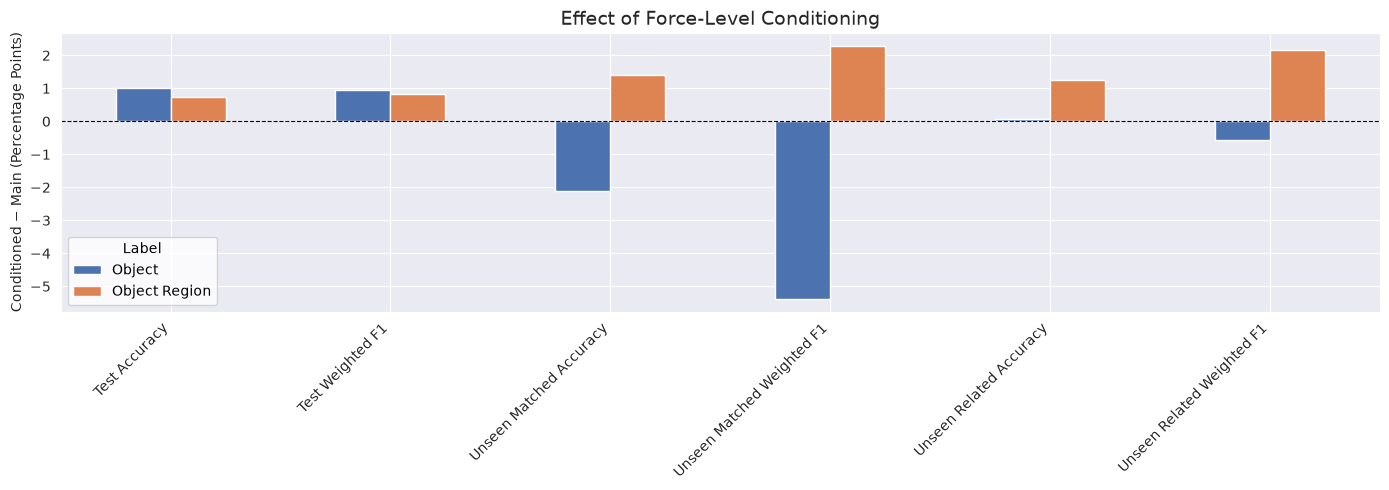

In [79]:
plot_conditioning_comparison(conditioning_comparison)